# Did San Francisco graffiti 311 calls decrease in 2020 due to COVID?

**Hypothesis:** graffiti calls decreased in 2020 as a result of COVID.

**Data:** DataSF "311 Cases" (Socrata `vw6y-z8j6`), graffiti requests (`service_name like '%Graffiti%'`), 2017–2022.

This notebook loads the processed aggregates produced by `scripts/analyze.py` (run `python scripts/download_data.py` then `python scripts/analyze.py` first) and walks through the answer.

> **Short answer:** *Nuanced.* There was a sharp, temporary drop during the strict spring-2020 lockdown (Apr–Jun 2020, **−32%** vs 2019), but calls rebounded strongly in the second half of the year, so the **full-year 2020 total was actually slightly higher than 2019**. The hypothesis holds only for the lockdown window, not the year.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PROC = ROOT / 'data' / 'processed'

yearly = pd.read_csv(PROC / 'graffiti_yearly.csv')
monthly = pd.read_csv(PROC / 'graffiti_monthly.csv', parse_dates=['date'])
yearly

,year,calls
0,2017,72420
1,2018,68722
2,2019,57035
3,2020,59051
4,2021,71156
5,2022,78953


## Annual view — no full-year decline

If COVID had suppressed graffiti reporting across 2020, we would expect the 2020 bar to sit clearly below 2019. It does not.

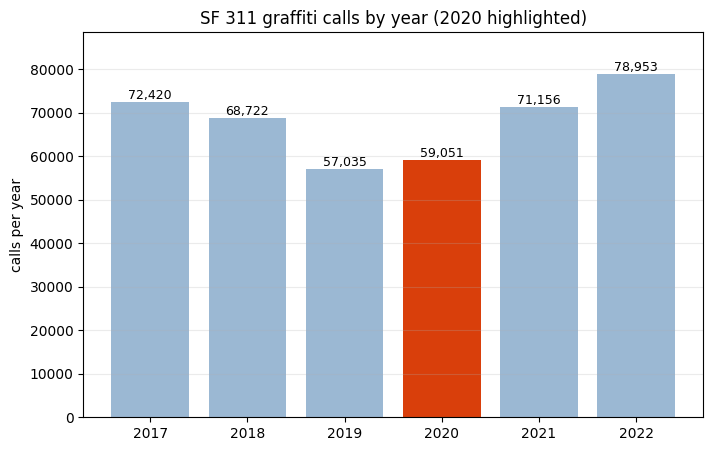

2019: 57,035   2020: 59,051   change: +3.5%


In [2]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#d93f0b' if y == 2020 else '#9bb8d3' for y in yearly['year']]
ax.bar(yearly['year'].astype(str), yearly['calls'], color=colors)
for x, v in zip(yearly['year'].astype(str), yearly['calls']):
    ax.text(x, v + 700, f'{v:,}', ha='center', fontsize=9)
ax.set_title('SF 311 graffiti calls by year (2020 highlighted)')
ax.set_ylabel('calls per year')
ax.set_ylim(top=yearly['calls'].max() * 1.12)
ax.grid(axis='y', alpha=0.25)
plt.show()

y = yearly.set_index('year')['calls']
print(f"2019: {y[2019]:,}   2020: {y[2020]:,}   change: {100*(y[2020]-y[2019])/y[2019]:+.1f}%")

2020 came in **~3.5% above** 2019. At the annual level, the hypothesis is **not** supported.

## Monthly view — a sharp lockdown trough

The annual number hides the within-year story. SF's shelter-in-place began **March 17, 2020**.

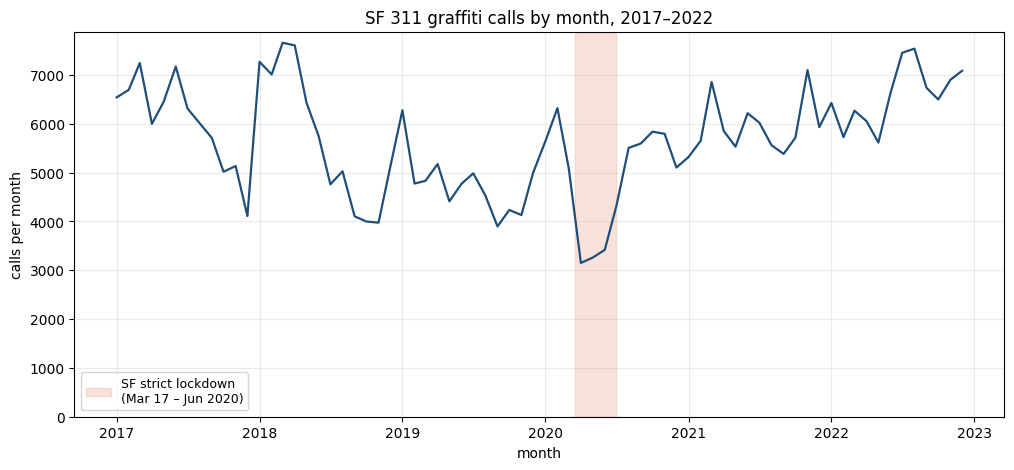

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly['date'], monthly['calls'], color='#1f4e79', lw=1.6)
ax.axvspan(pd.Timestamp('2020-03-17'), pd.Timestamp('2020-06-30'),
           color='#d93f0b', alpha=0.15, label='SF strict lockdown\n(Mar 17 – Jun 2020)')
ax.set_title('SF 311 graffiti calls by month, 2017–2022')
ax.set_ylabel('calls per month'); ax.set_xlabel('month')
ax.set_ylim(bottom=0); ax.grid(alpha=0.25); ax.legend(loc='lower left', fontsize=9)
plt.show()

The shaded lockdown window is the single deepest trough in the whole series — calls fell to ~3,150/month, well below the typical 4,500–6,500. Let's quantify the lockdown dip and the rebound.

In [4]:
m = monthly.set_index([monthly['date'].dt.year, monthly['date'].dt.month])['calls']

def window(year, months):
    return sum(int(m.get((year, mo), 0)) for mo in months)

def pct(a, b):
    return 100 * (a - b) / b

spring = [4, 5, 6]
fall = list(range(7, 13))
print(f"Apr–Jun 2020 vs 2019: {window(2020,spring):,} vs {window(2019,spring):,}  ({pct(window(2020,spring),window(2019,spring)):+.1f}%)")
print(f"Jul–Dec 2020 vs 2019: {window(2020,fall):,} vs {window(2019,fall):,}  ({pct(window(2020,fall),window(2019,fall)):+.1f}%)")

Apr–Jun 2020 vs 2019: 9,828 vs 14,362  (-31.6%)
Jul–Dec 2020 vs 2019: 32,174 vs 26,785  (+20.1%)


## Conclusion

- **Strict lockdown (Apr–Jun 2020): calls fell ~32% vs the same months in 2019.** This is a clear, COVID-timed decline.
- **Second half of 2020: calls rebounded ~20% above 2019**, pushing the full-year total slightly *above* 2019.
- So the hypothesis is **true only for the lockdown window**, not for the year: COVID produced a sharp but short-lived dip, not a sustained decrease.

**Important caveat:** 311 counts measure *reports*, not graffiti *incidence*. With far fewer people out during the strict lockdown, the drop plausibly reflects reduced **reporting** (and less-visited public space) rather than less graffiti being created. This analysis can distinguish *when* calls fell, but not *why*, from these data alone.